## Анализ задержек рейсов (данные BTS/DOT, 2024)

### Вопросы:

- Какая средняя задержка прилёта?
- Как распределены задержки? (гистограмма)
- Есть ли маршруты, где задержки почти всегда? Какая — самая непунктуальная?
- По каким причинам чаще всего возникают задержки?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('flight_data_2024_sample.csv', parse_dates=['fl_date'])


In [ ]:
#Поиск дубликатов
duplicates = df.duplicated().sum()
if duplicates == 0:
    result = 'Дубликаты не найдены'
else: 
    result = f'Дубли строк: {duplicates}'
print(result)

#Сравниваю количество аэропортов
dest_cnt = df['dest'].nunique()
origin_cnt = df['origin'].nunique()
print(f"Количество аэропортов отправления: {origin_cnt}")
print(f"Количество аэропортов прибытия: {dest_cnt}")

# Проверяю колонки 'origin' и 'dest' на симметричность
if set(df['origin']) == set(df['dest']):
    result = 'Данные по аэропортам симметричны'
else:
    result = 'Названия аэропортов отправления и прибытия не совпадают'
print(result)        


Дубликаты не найдены
Количество аэропортов отправления: 284
Количество аэропортов прибытия: 287
Названия аэропортов отправления и прибытия не совпадают


In [ ]:
# Проверяю типы данных по задержке рейсов отправления и прибытия
print(f"Задержка вылета: {df['dep_delay'].info()}")
print(f"Задержка прилета: {df['arr_delay'].info()}")

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: dep_delay
Non-Null Count  Dtype  
--------------  -----  
9884 non-null   float64
dtypes: float64(1)
memory usage: 78.3 KB
Задержка вылета: None
<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: arr_delay
Non-Null Count  Dtype  
--------------  -----  
9836 non-null   float64
dtypes: float64(1)
memory usage: 78.3 KB
Задержка прилета: None


In [ ]:
#Проверяю пропуски в колонках 'arr_delay' и 'dep_delay'
arr_delay_nan = df['arr_delay'].isna().sum()
dep_delay_nan = df['dep_delay'].isna().sum()
print(f"Количество пропусков в 'arr_delay': {arr_delay_nan}")
print(f"Количество пропусков в 'dep_delay': {dep_delay_nan}")

Количество пропусков в 'arr_delay': 164
Количество пропусков в 'dep_delay': 116


In [27]:
#Проверяю пропуски в колонке 'cancelled'
cancelled_nan = df['cancelled'].isna().sum()
print(f"Количество пропусков в 'cancelled': {cancelled_nan}")

#Считаю сколько отмененных рейсов имеют данные по задержке
anomalies1 = df[(df['cancelled'] == 1) & (df['arr_delay'].isna() | df['dep_delay'].isna())].shape[0]
print(f"Количество отмененных рейсов с данными по задержке(аномалия): {anomalies1}")

Количество пропусков в 'cancelled': 0
Количество отмененных рейсов с данными по задержке(аномалия): 122


In [24]:
anomalies2 = df[
    (df['cancelled'] == 1) & 
    ((df['dep_delay'].notna()) | (df['arr_delay'].notna()))
]

print(f"Найдено аномалий: {len(anomalies2)}")
print(anomalies2[['fl_date','cancelled','dep_delay','arr_delay','dep_time','arr_time']].head(10))

Найдено аномалий: 6
        fl_date  cancelled  dep_delay  arr_delay  dep_time  arr_time
2068 2024-07-31          1       51.0        NaN    1546.0       NaN
2844 2024-01-08          1       -8.0        NaN    1141.0       NaN
3330 2024-02-09          1       -9.0        NaN     721.0       NaN
4608 2024-01-20          1        0.0        NaN    1615.0       NaN
6812 2024-06-19          1        0.0        NaN    1130.0       NaN
8205 2024-04-20          1       25.0        NaN     600.0       NaN


Обнаружено два типа аномалий среди отменённых рейсов:

122 рейса — имеют данные о задержке, но не имеют времени вылета. Это, вероятно, техническая особенность данных (ошибка заполнения или неполная запись).

6 рейсов — имеют данные о задержке и время вылета, но не имеют времени прилёта. Это, вероятно, реальные случаи отмены рейса после вылета (возврат, перенаправление, техническая причина).

При расчёте статистики отмененные рейсы исключаю, так как они могут исказить результаты.

In [21]:
#Убираю из данных отмененные рейсы (~1.3%) и копирую таблицу без них, чтобы увидеть картину только по фактически выполненным рейсам
df_actual = df[df['cancelled'] == 0].copy()
#Заполняю пропуски '0'
df_actual['arr_delay'] = df_actual['arr_delay'].fillna(0)
df_actual['dep_delay'] = df_actual['dep_delay'].fillna(0)

In [44]:
# Считаю среднее время задержки вылета и прилета
avg_dep_delay = df_actual['dep_delay'].mean()
avg_arr_delay = df_actual['arr_delay'].mean()

# Считаю медиану задержки вылета и прилета
median_dep_d = df_actual['dep_delay'].median()
median_arr_d = df_actual['arr_delay'].median()

#Считаю стандартное отклонение задержки вылета и прилета
dep_std = np.std(df_actual['dep_delay'])
arr_std = np.std(df_actual['arr_delay'])

#Считаю максимальное время задержки вылета и прилета
dep_delay_max = df_actual['dep_delay'].max()
arr_delay_max = df_actual['arr_delay'].max()

print("Статистика задержки вылета:")
print(f"Среднее время: {round(avg_dep_delay,2)} минут.")
print(f"Медиана: {round(median_dep_d,2)} минут.")
print(f"Стандартное отклонение: {round(dep_std,2)} минут.")
print(f"Максимальное время задержки: {round(dep_delay_max,2)} минут.")
print()
print("Статистика задержки прилета:")
print(f"Среднее время: {round(avg_arr_delay,2)} минут.")
print(f"Медиана задержки: {round(median_arr_d,2)} минут.")
print(f"Стандартное отклонение: {round(arr_std,2)} минут.")
print(f"Максимальное время задержки: {round(arr_delay_max,2)} минут.")

Статистика задержки вылета:
Среднее время: 13.0 минут.
Медиана: -2.0 минут.
Стандартное отклонение: 53.63 минут.
Максимальное время задержки: 2011.0 минут.

Статистика задержки прилета:
Среднее время: 7.51 минут.
Медиана задержки: -6.0 минут.
Стандартное отклонение: 55.68 минут.
Максимальное время задержки: 2014.0 минут.


В среднем рейсы задерживаются на 7–13 минут, но медиана отрицательная — это значит, что половина рейсов вылетает и прилетает даже раньше расписания. Длинный хвост задержек (до 2000 минут) создаётся небольшим числом рейсов с экстремальными задержками, которые сильно увеличивают среднее.

C:\Users\79524_wpxtvz5\AppData\Local\Temp\ipykernel_2876\1421317639.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


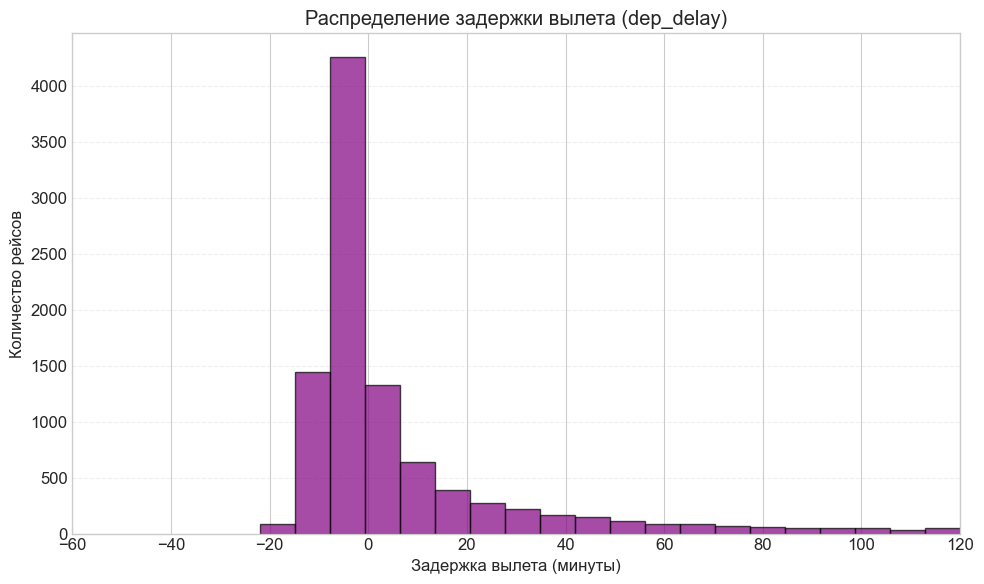

In [ ]:
# Отфильтровываем задержки в нужном диапазоне
dep_delay_filtered = df['dep_delay'][(df['dep_delay'] >= -60) & (df['dep_delay'] <= 120)]

# Строим гистограмму распределения задержек
plt.style.use('seaborn-v0_8-whitegrid')  
plt.rcParams['figure.figsize'] = (12, 6)  
plt.rcParams['font.size'] = 12

plt.figure(figsize=(10, 6))
plt.hist(dep_delay_filtered, bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.title('Распределение задержки вылета (dep_delay)')
plt.xlabel('Задержка вылета (минуты)')
plt.ylabel('Количество рейсов')
plt.xlim(-60, 120)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

- Основная масса рейсов вылетает в диапазоне от −15 до +20 минут.
- Распределение имеет длинный правый хвост: есть рейсы с задержками более 60 минут, но их доля невелика, операционная дисциплина в целом хорошая
- Длинный правый хвост подтверждает, что средняя задержка (13мин) выше медианы (-2мин), из-за редких, но очень долгих задержек.

C:\Users\79524_wpxtvz5\AppData\Local\Temp\ipykernel_2876\2108086437.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


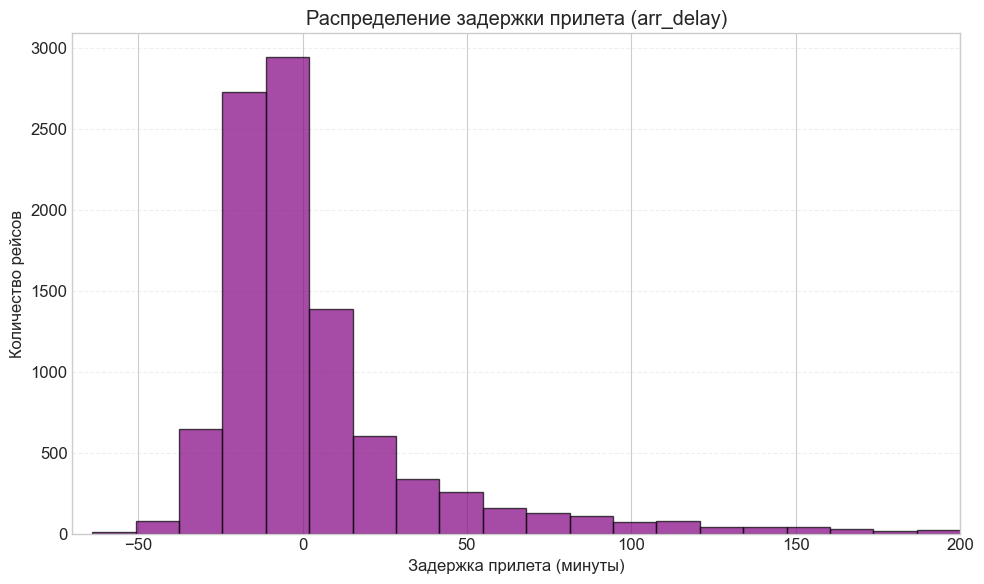

In [14]:
# Отфильтровываем задержки в нужном диапазоне
arr_delay_filtered = df['arr_delay'][(df['arr_delay'] >= -70) & (df['arr_delay'] <= 200)]

# Строим гистограмму распределения задержек прилета
plt.style.use('seaborn-v0_8-whitegrid')  
plt.rcParams['figure.figsize'] = (12, 6)  
plt.rcParams['font.size'] = 12

plt.figure(figsize=(10, 6))
plt.hist(arr_delay_filtered, bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.title('Распределение задержки прилета (arr_delay)')
plt.xlabel('Задержка прилета (минуты)')
plt.ylabel('Количество рейсов')
plt.xlim(-70, 200)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

- Основная масса рейсов прилетает с диапазоном от −30 до +30 минут задержки.
- Медианная задержка составляет −6 минут, что указывает на склонность рейсов прилетать раньше времени.
- Длинный правый хвост подтверждает, что средняя задержка (7.5мин) выше медианы (-6мин): значение смещено вправо за счёт редких, но экстремально долгих задержек (более 100 минут)


Какая авиакомпания самая непунктуальная?

In [54]:
#Сгруппирую данные по компаниям-перевозчикам
unique_carrier = df_actual.groupby('op_unique_carrier')

#Посчитаю количество рейсов
flights_cnt = unique_carrier.size()

#Посчитаю среднюю задержку прилета
avg_carrier_delay = unique_carrier['arr_delay'].mean()

#Посчитаю медиану
median_delay = unique_carrier['arr_delay'].median()

#Создаю таблицу "Среднее время задержки по перевозчикам (с количеством рейсов)"
merged = flights_cnt.reset_index().merge(
    avg_carrier_delay.reset_index(),
    on='op_unique_carrier',
    how='inner'
).merge(
    median_delay.reset_index(),
    on='op_unique_carrier',
    how='inner'
)
merged.columns = ['unique_carrier', 'flights', 'avg_delay','median']
merged = merged[merged['flights'] >= 1000].sort_values('avg_delay',ascending=False)
print("Среднее время задержки среди крупных перевозчиков (>1000 рейсов):")
print(merged)

Среднее время задержки среди крупных перевозчиков (>1000 рейсов):
   unique_carrier  flights  avg_delay  median
1              AA     1363  16.162876    -4.0
11             OO     1071   9.083100    -7.0
13             WN     2002   5.960040    -4.0
12             UA     1022   5.328767    -8.0
4              DL     1450   3.528276    -7.5


Среди крупных перевозчиков (более 1000 рейсов за 2024 год) самая высокая средняя задержка прилёта у American Airlines — 16.2 минуты. При этом медиана у AA составляет -4 минуты, что означает: половина рейсов AA вылетает даже раньше расписания, но редкие и очень долгие задержки создают высокое среднее. Самая пунктуальная среди крупных — Delta (3.5 минуты).

Есть ли маршруты, где задержки почти всегда?

In [82]:
# Поиск маршрутов с самой высокой долей задержки (>15 мин)
df_actual['route'] = df_actual['origin'] + '-' + df_actual['dest']

# Группирую данные (количество рейсов >18, задержка >15 минут) и вычисляю статистику
route_stats = df_actual.groupby('route')['arr_delay'].agg(['count','mean',lambda x: (x>15).mean() * 100])
route_stats.columns = ['total_flights', 'avg_delay', 'delay_pct(>15min)']
route_stats_filtred = route_stats[route_stats['total_flights'] > 18]
route_stats_sorted = route_stats_filtred.sort_values('delay_pct(>15min)', ascending=False)
print("Топ-5 маршрутов с высокой долей задержки >15 минут:")
print(route_stats_sorted.head(5))


Топ-5 маршрутов с высокой долей задержки >15 минут:
         total_flights  avg_delay  delay_pct(>15min)
route                                               
LAX-LAS             19  -2.473684          21.052632
OGG-HNL             21   1.857143           9.523810
JFK-LAX             21  -8.571429           9.523810
LAX-JFK             24  -9.208333           4.166667
HNL-OGG             20  -3.450000           0.000000


### Маршруты с задержками (> 18 рейсов за год)
- **Самый проблемный маршрут:** LAX–LAS (Лос-Анджелес – Лас-Вегас) — 21% рейсов с задержкой > 15 минут. Однако средняя задержка на маршруте отрицательная (-2.5 мин), что указывает на единичные, но очень долгие задержки, а не на системную проблему.
- **Трансконтинентальные маршруты** (JFK–LAX, LAX–JFK) показывают отрицательную среднюю задержку (-8...-9 мин) и низкую долю задержек (4–10%), что говорит о хорошей пунктуальности на дальних магистралях.
- **Островные маршруты** (OGG–HNL, HNL–OGG) — самые пунктуальные: доля задержек не превышает 10%, а на HNL–OGG составляет 0%.

## По каким причинам чаще всего возникают задержки?

In [ ]:
# Поиск пропусков в колонках с причинами
search_nan = df_actual[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].isna().sum() 
print("Количество пропусков в причинах:") 
print(search_nan)

Количество пропусков в причинах:
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64


In [89]:
# Считаю, сколько минут составила задержка по каждой причине
reasons_sum = df_actual[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].sum()
print("Сколько минут составила задержка по каждой причине:") 
print(reasons_sum.sort_values(ascending=False))

Сколько минут составила задержка по каждой причине:
late_aircraft_delay    61422
carrier_delay          48709
nas_delay              30271
weather_delay          10831
security_delay            88
dtype: int64


Большинство задержек (~73%) вызваны двумя причинами — задержкой предыдущего рейса и проблемами авиакомпании.
Это означает, что основные рычаги влияния на пунктуальность находятся внутри авиакомпаний и их операционной логистики.

In [92]:
#Считаю среднюю задержку по каждой причине
reasons_mean = df_actual[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].apply(lambda x: x[x>0].mean())
print("Cредняя задержка по каждой причине (мин):") 
print(reasons_mean.sort_values(ascending=False))

Cредняя задержка по каждой причине (мин):
weather_delay          76.815603
late_aircraft_delay    57.673239
carrier_delay          42.877641
nas_delay              28.665720
security_delay         14.666667
dtype: float64


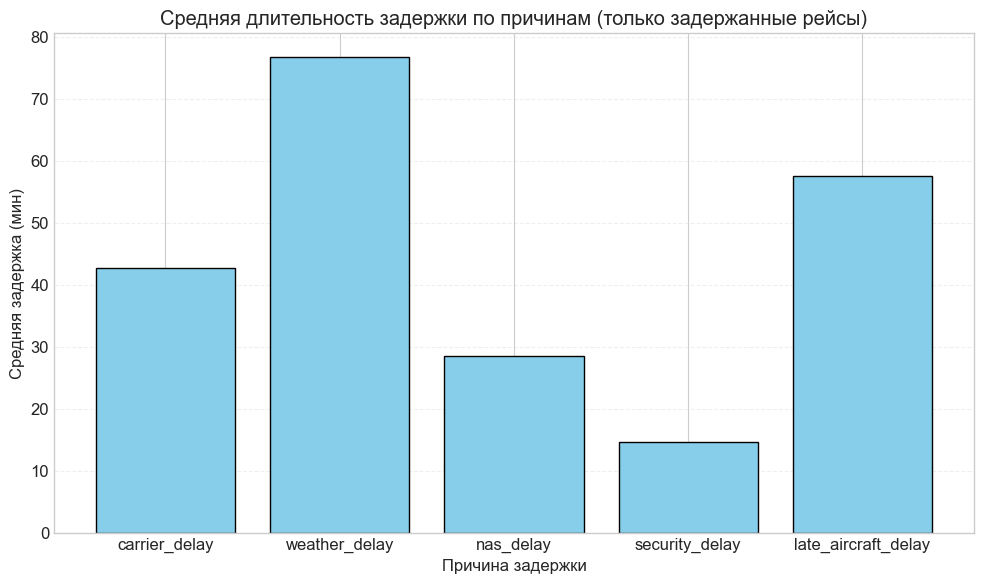

In [93]:
plt.style.use('seaborn-v0_8-whitegrid') 
plt.rcParams['figure.figsize'] = (12, 6)  
plt.rcParams['font.size'] = 12

plt.figure(figsize=(10, 6))
plt.bar(reasons_mean.index, reasons_mean.values, color='skyblue', edgecolor='black')
plt.title('Средняя длительность задержки по причинам (только задержанные рейсы)')
plt.xlabel('Причина задержки')
plt.ylabel('Средняя задержка (мин)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

При плохих погодных условиях - задержка рейсов в среднем на 1 час 28 минут. Это самые долгие задержки, но их не так много. 

Основной объём задержек создают задержка предыдущего рейса и проблемы авиакомпании.